# **Demo Notebook run by me (the author) on the Penn State ICDS ROAR SLURM Cluster (Just one A100 40GB) to show how the per-token prediction output looks for an example image from the test set.**

### Note that, this version is of <ins>HDFLIM (P)</ins> **without the prompt template for polishing** (check the paper for more details; <ins>HDFLIM (C)</ins> doesn't use polishing)

In [ ]:
#importing the libraries
import pandas as pd
import torch
from numpy import array
import numpy as np
import os
from PIL import Image
import requests
from tqdm import tqdm
from VisionModel_utils import FrozenVisionModel_Encoding
from LangModel_utils import FrozenLanguageModel_Encoding
import json
from transform_inference import make_transform
import argparse
from datetime import datetime

In [ ]:
def pack_boolean_tensor(token_hd_vec):
    """
    Convert a boolean tensor to packed uint8 format (NumPy fallback if torch.packbits is missing).
    Optimized for CPU.
    """
    token_hd_vec_uint8 = token_hd_vec.to(torch.uint8, copy=False)

    if hasattr(torch, "packbits"): # This was available in some PyTorch versions
        try:
            return torch.packbits(token_hd_vec_uint8, dim=-1)
        except Exception:
            pass  # fallback if torch.packbits fails (rare older builds)

    arr = token_hd_vec_uint8.numpy()
    packed = np.packbits(arr, axis=-1)
    return torch.from_numpy(packed)

class HDLogitsComputer:
    """Fast HD logits computation with pre-allocated buffers and max pooling"""
    def __init__(self, vocab_hd_packed, popcount_lut, device='cuda:0', pooling='max'):
        self.device = device
        self.vocab_hd_packed = vocab_hd_packed
        self.popcount_lut = popcount_lut
        self.vocab_size = vocab_hd_packed.shape[1]
        self.pooling = pooling  # 'max' or 'sum'
        
        # Pre-allocate buffers (reused across ALL calls)
        self.HD_logits_gpu = torch.zeros(self.vocab_size, device=device, dtype=torch.float32)
        self.HD_logits_cpu = torch.zeros(self.vocab_size, device='cuda:0', dtype=torch.float32)
        
    def compute(self, token_hd_vec, i, window_size=4, vocab_chunk_size=30000):
        start_pos = max(0, i)
        end_pos = min(self.vocab_hd_packed.shape[0], i + window_size + 1)
        window_len = end_pos - start_pos
        
        # Move token to GPU
        token_hd_vec = token_hd_vec.to(self.device, non_blocking=True)
        token_hd_expanded = token_hd_vec.unsqueeze(0).unsqueeze(0)
        
        # Reset buffer
        self.HD_logits_gpu.zero_()
        
        # Optimization: Load entire window once (window_size=4 means max 9 positions)
        if window_len <= 10:
            vocab_window = self.vocab_hd_packed[start_pos:end_pos].to(self.device, non_blocking=True)
            
            for v_start in range(0, self.vocab_size, vocab_chunk_size):
                v_end = min(v_start + vocab_chunk_size, self.vocab_size)
            
                if v_end == v_start:
                    continue  # nothing to process
            
                xor_result = torch.bitwise_xor(vocab_window[:, v_start:v_end, :], token_hd_expanded)
                hamming_distances = self.popcount_lut[xor_result.long()].sum(dim=2, dtype=torch.int32)
            
                if self.pooling == 'max':
                    self.HD_logits_gpu[v_start:v_end] = (50000 - hamming_distances).max(dim=0)[0].float()

                else:
                    # Sum pooling: sum similarities across window
                    self.HD_logits_gpu[v_start:v_end] = (50000 - hamming_distances).sum(dim=0, dtype=torch.float32)
            
            del vocab_window
        else:
            """"
            Currently Else part is not needed as window size is small
            Also, still working on this part so might not work when used.
            Additonally, should be very slow.... 
            """
            # Fallback for larger windows
            # Fallback for larger windows
            for v_start in range(0, self.vocab_size, vocab_chunk_size):
                v_end = min(v_start + vocab_chunk_size, self.vocab_size)
                
                vocab_chunk = self.vocab_hd_packed[start_pos:end_pos, v_start:v_end, :].to(self.device, non_blocking=True)
                xor_result = torch.bitwise_xor(vocab_chunk, token_hd_expanded)
                hamming_distances = self.popcount_lut[xor_result.long()].sum(dim=2, dtype=torch.int32)
                
                # Apply pooling operation
                if self.pooling == 'max':
                    self.HD_logits_gpu[v_start:v_end] = (50000 - hamming_distances).max(dim=0)[0].float()
                else:
                    self.HD_logits_gpu[v_start:v_end] = (50000 - hamming_distances).mean(dim=0, dtype=torch.float32)
                
                del vocab_chunk, xor_result, hamming_distances
        
        # Normalize in-place (adjust divisor for max pooling)
        if self.pooling == 'max':
            self.HD_logits_gpu.div_(1.0)  # No window length normalization needed
        else:
            self.HD_logits_gpu.div_(1.0)
        
        # Copy to cuda:0 (reuse buffer)
        self.HD_logits_cpu.copy_(self.HD_logits_gpu, non_blocking=False)
        
        del token_hd_expanded
        torch.cuda.empty_cache()
        
        return self.HD_logits_gpu

def LLM_get_next_token_logits(model, tokenizer, tokens, device):
    """
    Get probabilities for the next token given a list of tokens.
    
    Args:
        model: The language model
        tokenizer: The tokenizer
        tokens: List of token IDs or a string
        device: Device to run on
    
    Returns:
        next_token_logits: Tensor of logits for all tokens in vocabulary
    """
    # Convert to token IDs if input is a string
    if isinstance(tokens, str):
        tokens = tokenizer.encode(tokens, return_tensors='pt').to(device)
    elif isinstance(tokens, list):
        tokens = torch.tensor([tokens]).to(device)
    else:
        tokens = tokens.to(device)
    
    # Get model output
    with torch.no_grad():
        outputs = model(tokens)
        logits = outputs.logits  # Shape: (batch_size, sequence_length, vocab_size)
    
    # Get logits for the last token (next token prediction)
    next_token_logits = logits[0, -1, :]  # Shape: (vocab_size,)
    
    return next_token_logits

In [ ]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'validation': 'data/validation-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet', 'restval': 'data/restval-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/yerevann/coco-karpathy/" + splits["test"])

In [ ]:
# Define device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Frozen Vision Model
F_VM_object= FrozenVisionModel_Encoding(device = device)
    
# Initialize Frozen Language Model
F_LM_object = FrozenLanguageModel_Encoding(device = device, AutoModelForCausalLM_flag=True)

INSIDE Constructor/Initializer function of FrozenVisionModel_Encoding class
Loading Dinov3.txt ..... 

Specified device to use:  cuda 

Specified HD dimension size:  50000 

Specified last hidden state dimension size:  1024 

Specified number of patches:  1025 

✓ Successfully loaded HD matrices from disk
  [1] img_LSH_matrix.pt
      Path: /storage/group/vuh14/default/Abhishek_files/dinov3txt_qwen3/saved_HD_mats/img_LSH_matrix.pt
      Shape: torch.Size([1024, 50000])
      Dtype: torch.bfloat16

  [2] img_pos_HD.pt
      Path: /storage/group/vuh14/default/Abhishek_files/dinov3txt_qwen3/saved_HD_mats/img_pos_HD.pt
      Shape: torch.Size([1, 1025, 50000])
      Dtype: torch.int16

Frozen Vision Model:  Dinov3.txt with HD LSH matrix instantiated succesfully! 

INSIDE Constructor/Initializer function of FrozenLanguageModel_Encoding class
Loading  Qwen/Qwen3-4B .....


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Frozen Language model  Qwen/Qwen3-4B summary:
Frozen Language model vocabulary size:-
151669
Frozen Language model tokenizer has the following special tokens map:-
{'eos_token': '<|im_end|>', 'pad_token': '<|im_end|>'}
Frozen Language model will truncate captions to size  43 tokens
Last hidden state dimension : 2560
Using device for Frozen Language model:  cuda
Checking if saved_HD_mats/LM_LSH_matrix.pt exists on disk
✓ Successfully loaded HD matrix from disk
  [1] LM_LSH_matrix.pt
      Path: /storage/group/vuh14/default/Abhishek_files/dinov3txt_qwen3/saved_HD_mats/LM_LSH_matrix.pt
      Shape: torch.Size([2560, 50000])
      Dtype: torch.bfloat16
Frozen Language Model:  Qwen/Qwen3-4B with HD LSH matrix instantiated succesfully! 



In [ ]:
# Load packed vocab predictors
packed_memmap = np.memmap("/storage/group/vuh14/default/Abhishek_files/dinov3txt_qwen3/saved_HD_mats/vocab_HD_packed_13M.dat", dtype=np.uint8, mode='r', shape=(43, 151669, 6250))
    
# Convert to torch tensor (creates view, no memory copy)
vocab_hd_packed = torch.from_numpy(packed_memmap[:]).clone()  # .clone() copies to RAM
# vocab_hd_packed = vocab_hd_packed[:21]
vocab_hd_packed = vocab_hd_packed[:41]

/storage/group/vuh14/default/Abhishek_files/.tmp/ipykernel_29307/3887149061.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  vocab_hd_packed = torch.from_numpy(packed_memmap[:]).clone()  # .clone() copies to RAM


In [ ]:
# Create a lookup table for popcount of all byte values (0-255)
POPCOUNT_TABLE = torch.tensor([bin(i).count('1') for i in range(256)], dtype=torch.uint8)

# ============= OPTIMIZATION: Initialize once, reuse =============
vocab_hd_packed_pinned = vocab_hd_packed.pin_memory()
popcount_lut_gpu = POPCOUNT_TABLE.to(device)  # Move once, keep on GPU

# Initialize the computer once with max pooling - REUSED ACROSS ALL IMAGES
hd_computer = HDLogitsComputer(vocab_hd_packed_pinned, popcount_lut_gpu, pooling='max')

In [ ]:
vocab_hd_packed.shape

torch.Size([41, 151669, 6250])

In [ ]:
transform = make_transform(resize_size=512, aspect_ratio_threshold=1.0)

In [ ]:
from semantic_clip import CLIPSemanticSampler
# Initialize sampler once (reuse across multiple captions)
sampler = CLIPSemanticSampler(
    lm_tokenizer=F_LM_object.tokenizer,
    clip_model=F_VM_object.model,
    clip_tokenizer=F_VM_object.clip_tokenizer.tokenize)

In [ ]:
from IPython.display import clear_output
def inferer_captions_using_HD(img, top_k, caption_size, window_length, fixed_temp, clip_weight):
    """
    The core function to infer captions using HD representations.
    Args:
        img: Input image (PIL Image)
        top_k: Top-k value for sampling
        caption_size: Maximum caption size
        window_length: Window length for HD computation
        fixed_temp: Fixed temperature for sampling
        clip_weight: Weight for CLIP similarity in logits computation
    Returns:
        pred_caption: Generated caption (string)
    """
    img_tensor = transform(img).unsqueeze(0)
    
    hidden_batches_imgs, clip_image_features = F_VM_object.get_h_img(img_tensor)
    clip_image_features /= clip_image_features.norm(dim=-1, keepdim=True)
    h_img = hidden_batches_imgs
    img_HD = F_VM_object.get_img_HD_vec(h_img)
    img_HD = torch.sign(img_HD)[0]
    pred_caption_tokens = [1986, 2168, 4933]
    
    i = 0
    while i < caption_size:
        
        i = len(pred_caption_tokens)-3
        if i>41:
            break
        toks, LM_rep_hidden = F_LM_object.get_h_caption(
            F_LM_object.tokenizer.decode(pred_caption_tokens)
        )

        LM_rep_HD = torch.sign(torch.matmul(LM_rep_hidden[0][-1], F_LM_object.LM_LSH_matrix))
        
        token_hd_vec = torch.sign(torch.mul(LM_rep_HD, img_HD))
        token_hd_vec = token_hd_vec > 0
        token_hd_vec = token_hd_vec.cpu()
        token_hd_vec = pack_boolean_tensor(token_hd_vec)

        HD_logits = hd_computer.compute(token_hd_vec, i, window_size=window_length)

        LLM_logits = LLM_get_next_token_logits(F_LM_object.model, F_LM_object.tokenizer, pred_caption_tokens, device)[:151669]

        HD_logits = HD_logits/HD_logits.max() + 0.15*LLM_logits/LLM_logits.max()
        
        predict_token_i = sampler.sample_next_token(
            logits=HD_logits,
            generated_tokens=pred_caption_tokens,
            clip_image_features=clip_image_features,
            temperature=fixed_temp, # CAN CHANGE PARARMS
            top_k=top_k,
            top_p=0.95,
            min_candidates= top_k,
            repetition_penalty=1.1,
            clip_weight=clip_weight
        )
                
        pred_caption_tokens.append(predict_token_i)

        # clear_output(wait=True)
        print(F_LM_object.tokenizer.decode(pred_caption_tokens))
        
        # if i > 1 and (pred_caption_tokens[-1] == F_LM_object.tokenizer.eos_token or pred_caption_tokens[-1] == 151645 or pred_caption_tokens[-1] == 13):
        #     break
    
    pred_caption = F_LM_object.tokenizer.decode(pred_caption_tokens)
    return pred_caption

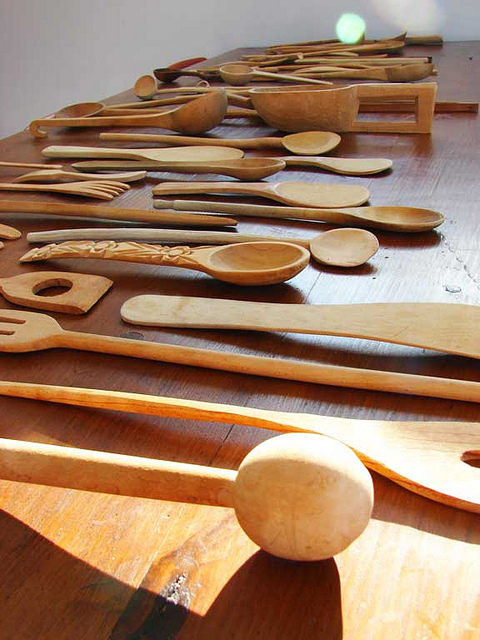

In [ ]:
i=4
url = df['url'][i]
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image

In [ ]:
inferer_captions_using_HD(image, top_k=80, caption_size=21, window_length=2, fixed_temp=1.0, clip_weight=0.5)

This image shows wooden
This image shows wooden spoon
This image shows wooden spoon tools
This image shows wooden spoon tools arranged
This image shows wooden spoon tools arranged horizontally
This image shows wooden spoon tools arranged horizontally.
This image shows wooden spoon tools arranged horizontally. Each
This image shows wooden spoon tools arranged horizontally. Each piece
This image shows wooden spoon tools arranged horizontally. Each piece is
This image shows wooden spoon tools arranged horizontally. Each piece is made
This image shows wooden spoon tools arranged horizontally. Each piece is made of
This image shows wooden spoon tools arranged horizontally. Each piece is made of wood
This image shows wooden spoon tools arranged horizontally. Each piece is made of wood,
This image shows wooden spoon tools arranged horizontally. Each piece is made of wood, which
This image shows wooden spoon tools arranged horizontally. Each piece is made of wood, which has
This image shows wo

'This image shows wooden spoon tools arranged horizontally. Each piece is made of wood, which has been carved or shaped into different sizes'